# Detection v1 — run & evaluate

Thin runner for the full cascade (L1 Stage1 → L2 Consolidator → L3 Classifier). Fits on the 90-recording
train split, checks the L3 window centring on the train split, evaluates on the 10 held-out test
recordings, saves the model. All logic lives in `src/` (`detect_config`, `detect_data`, `detection`,
`detect_metrics`); this notebook just wires it together.

**~5 min to run** (the L3 registration fit dominates; L1+L2 over all 90 recordings takes ~8 s).
Numbers are indicative — only ~5 test IEDs.

In [ ]:
import sys
from pathlib import Path
import warnings; warnings.filterwarnings('ignore')
sys.path.insert(0, str(Path('..') / 'src'))
from classify_loader import load_CSV
from detect_data import load_dataset, stratified_split
from detection import Config, DetectionPipeline
import detect_metrics as M

cfg = Config()
man = load_CSV(Path('..') / 'Kural_Dataset' / 'eeg_summary.csv')
train_df, test_df = stratified_split(man, n_test=cfg.n_test, seed=cfg.split_seed)   # 90 / 10, deterministic
REC = Path('..') / 'Kural_Dataset' / 'Recordings'
train = load_dataset(train_df, REC)
test  = load_dataset(test_df, REC)
print(f"{len(train)} train / {len(test)} test  ({sum(r['epi'] for r in test)} test IEDs)")

pipe = DetectionPipeline(cfg).fit(train)     # trains L3 on consolidated TRAIN candidates only
print('fit:', pipe.train_stats_)
pipe.save('../detect_model.joblib')          # shippable model (Config + fitted classifier)

90 train / 10 test  (5 test IEDs)
fit: {'windows': 5575, 'positives': 140}


## Window centring check (TRAIN only)

`event_window` re-centres each event before cutting the 2 s window the classifier sees. That choice is
potentially load-bearing: **Fisher-Rao registration is alignment-sensitive**, so if the re-centring lands
on the wrong extremum — an after-going slow wave, a baseline drift, the biphasic down-stroke — every FDA
feature is computed on a shifted curve, and L3's AUC would be depressed for a reason that has nothing to
do with the model. This section tests that.

`cfg.centre_on` picks the rule:
- `'amplitude'` — max |deviation from the local median| of the smoothed signal. Matches the annotation
  convention (marker at the spike peak) and how the classification-phase windows were cut, but the
  *largest* deflection near a spike is often the slow after-going component, not the spike.
- `'sharpness'` — max of the L1 statistic (|SG 2nd deriv| / MAD). Curvature peaks at the apex of a sharp
  transient, so a slow wave can't win.

Offsets below are measured against the **neurologist marker** (0 ms = the window centre sits exactly on
the annotated spike peak), over the 90-train only.

In [8]:
import numpy as np, matplotlib.pyplot as plt
from dataclasses import replace

off = {}                                  # centring rule -> (positive windows, offsets ms, recording ids)
for mode in ('amplitude', 'sharpness'):
    off[mode] = M.centring_offsets(DetectionPipeline(replace(cfg, centre_on=mode)), train)
    a = np.abs(off[mode][1])
    print(f"centre_on={mode:<10s} n={len(a):3d}   |offset| median {np.median(a):3.0f} ms  "
          f"p90 {np.percentile(a, 90):3.0f} ms  max {a.max():3.0f} ms   >100 ms: {(a > 100).mean():.0%}")

centre_on=amplitude  n=140   |offset| median  54 ms  p90 154 ms  max 238 ms   >100 ms: 22%
centre_on=sharpness  n=140   |offset| median  20 ms  p90  86 ms  max 152 ms   >100 ms: 1%


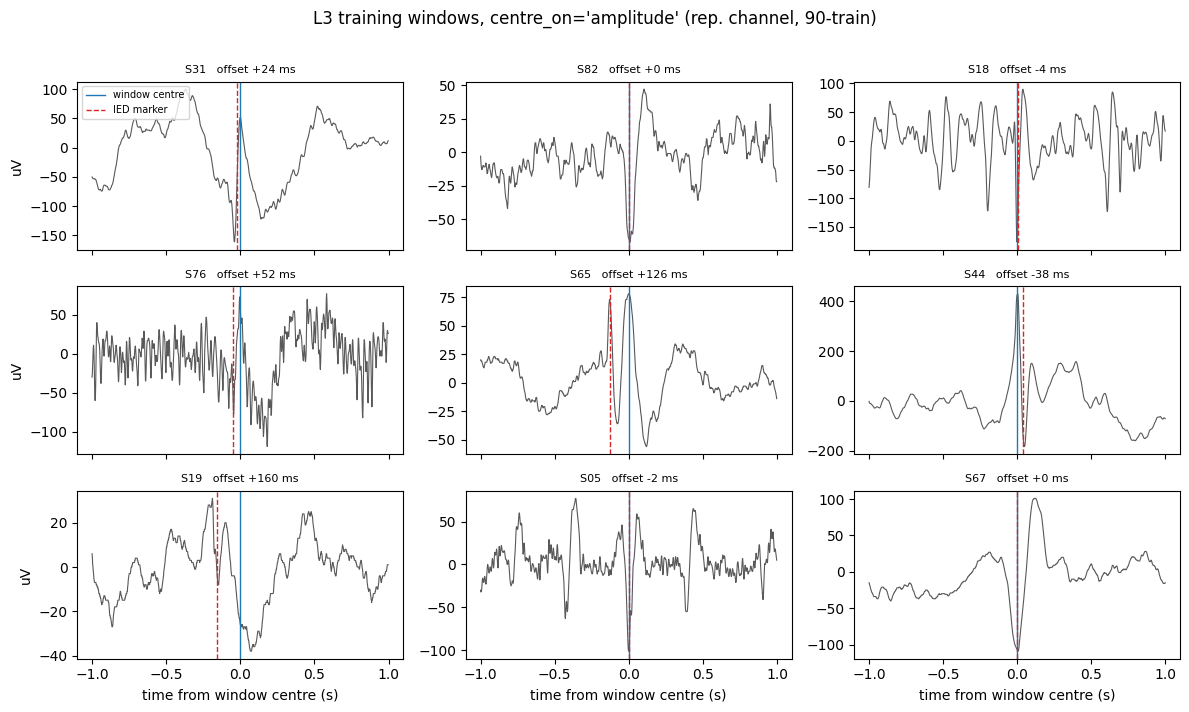

In [9]:
# eyeball 9 IED windows (one per recording) under the configured rule: centre should sit on the marker
W, offs, fids = off[cfg.centre_on]
seen, pick = set(), []
for i, f in enumerate(fids):
    if f not in seen:
        seen.add(f); pick.append(i)
t = (np.arange(W.shape[1]) - W.shape[1] // 2) / cfg.sfreq

fig, axs = plt.subplots(3, 3, figsize=(12, 7), sharex=True)
for ax, i in zip(axs.ravel(), pick[:9]):
    ax.plot(t, W[i], lw=0.8, color='0.35')
    ax.axvline(0, color='C0', lw=1.0, label='window centre')
    ax.axvline(-offs[i] / 1000, color='C3', ls='--', lw=1.0, label='IED marker')
    ax.set_title(f"{fids[i]}   offset {offs[i]:+.0f} ms", fontsize=8)
axs[0, 0].legend(fontsize=7, loc='upper left')
for ax in axs[-1]:
    ax.set_xlabel('time from window centre (s)')
for ax in axs[:, 0]:
    ax.set_ylabel('uV')
plt.suptitle(f"L3 training windows, centre_on='{cfg.centre_on}' (rep. channel, 90-train)", y=1.01)
plt.tight_layout()
plt.savefig(f'../figures/detection_window_centring_{cfg.centre_on}.png', dpi=800, bbox_inches='tight')
plt.show()

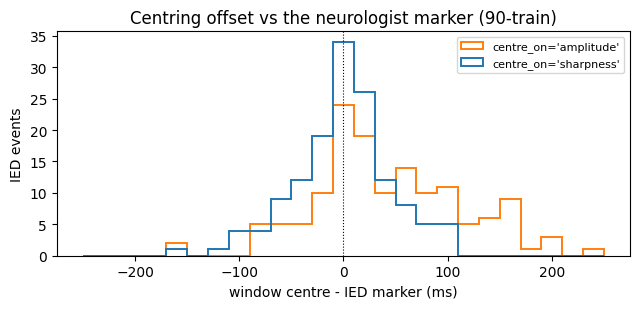

In [10]:
fig, ax = plt.subplots(figsize=(6.5, 3.2))
for mode, c in (('amplitude', 'C1'), ('sharpness', 'C0')):
    ax.hist(off[mode][1], bins=np.arange(-250, 251, 20), histtype='step', lw=1.4, color=c,
            label=f"centre_on='{mode}'")
ax.axvline(0, color='k', ls=':', lw=0.8)
ax.set_xlabel('window centre - IED marker (ms)'); ax.set_ylabel('IED events')
ax.set_title('Centring offset vs the neurologist marker (90-train)'); ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('../figures/detection_centring_offsets.png', dpi=800, bbox_inches='tight')
plt.show()

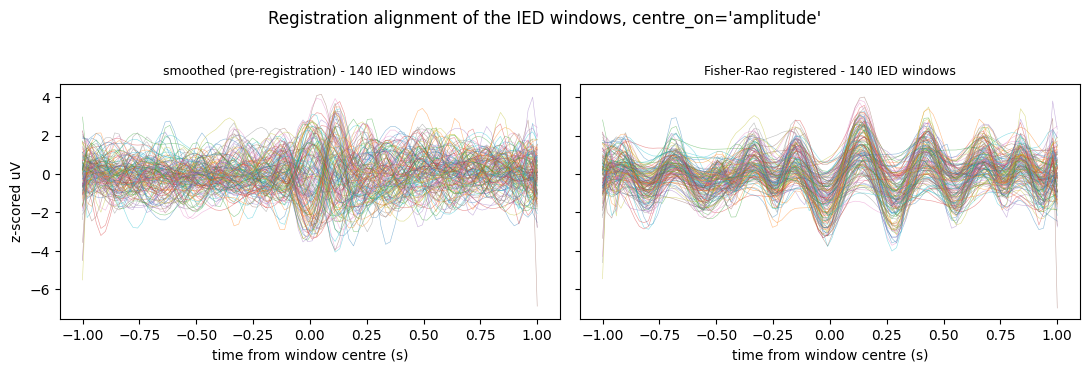

In [11]:
# do the positive windows stack once registered? (the curves the LR actually sees)
sm, al = pipe.classifier.aligned_curves(off[cfg.centre_on][0])
z = lambda A: (A - A.mean(1, keepdims=True)) / (A.std(1, keepdims=True) + 1e-12)
tt = np.linspace(-cfg.classifier_halfwin_s, cfg.classifier_halfwin_s, sm.shape[1])

fig, axs = plt.subplots(1, 2, figsize=(11, 3.6), sharey=True)
for ax, A, ttl in ((axs[0], sm, 'smoothed (pre-registration)'), (axs[1], al, 'Fisher-Rao registered')):
    ax.plot(tt, z(A).T, lw=0.4, alpha=0.5)
    ax.set_title(f"{ttl} - {len(A)} IED windows", fontsize=9)
    ax.set_xlabel('time from window centre (s)')
axs[0].set_ylabel('z-scored uV')
plt.suptitle(f"Registration alignment of the IED windows, centre_on='{cfg.centre_on}'", y=1.02)
plt.tight_layout()
plt.savefig(f'../figures/detection_registration_alignment_{cfg.centre_on}.png', dpi=800, bbox_inches='tight')
plt.show()

### What this showed (90-train, 140 IED windows over 49 epileptic recordings)

| `centre_on` | median \|offset\| | p90 | max | >100 ms off | grouped-CV AUC |
|---|---|---|---|---|---|
| `'amplitude'` (default) | 54 ms | 154 ms | 238 ms | **22%** | **0.669** |
| `'sharpness'` | 20 ms | 86 ms | 152 ms | **1%** | 0.617 |

**The centring suspicion was real but harmless.** The amplitude rule genuinely does misalign a fifth of
the training positives — visible in the panels, where on S65 (+126 ms) and S19 (+160 ms) the centre jumped
to the after-going slow wave while the marker sat on the sharp spike. Re-centring on the L1 sharpness
statistic fixes the alignment almost completely (1% beyond 100 ms).

**It does not raise the AUC.** Grouped 5-fold CV by recording over all 90-train candidates
(`M.grouped_cv_auc(pipe, train)`, ~20 min): 0.669 amplitude vs 0.617 sharpness; a recording-level
bootstrap puts the difference at **+0.051 in favour of amplitude, 95% CI [0.000, +0.105]**. So marker
fidelity is not what the FDA features want — plausibly because FPCA is amplitude-sensitive and centring
on the largest deflection puts the dominant feature at a fixed location, while Fisher-Rao warping absorbs
the residual shift. **`centre_on` stays `'amplitude'`; centring is ruled out as the AUC bottleneck**, so
the remaining L3 lever is hard-negative mining, then L4 spatial features.

Also useful: that CV gives the **trustworthy L3 number, AUC 0.669 over 48 train IEDs** — per-fold 0.57 ·
0.67 · 0.83 · 0.67 · 0.68. The 5-IED test AUC (0.683 below) is far too noisy to tune against.

Two caveats for the writeup:
- **Don't score the centring rules by how tightly the windows stack.** That comparison is circular: each
  rule maximises self-similarity at its own centre, so the "tighter" overlay is the one that centres on
  the biggest deflection regardless of whether that is the IED. The offset to the neurologist marker is
  the only alignment measure here that uses information from outside the rule being tested.
- The registration overlay is a *sanity* check (do the curves stack on a common shape?), not a metric —
  Fisher-Rao elastic warping can absorb part of a centring error, which is exactly why the AUC effect had
  to be measured rather than inferred from the offsets.

In [12]:
print('=== TEST (10 recordings) ===')
M.report(pipe, test)

=== TEST (10 recordings) ===
  L1 IED recall            : 1.00
  L2 consolidation recall  : 1.00
  L3 classifier AUC (test) : 0.683
  localisation error (ms)  : 4
  centre baseline          : sens 0.40, 4.0 FP/min  (to beat)
  FROC — best sensitivity at FP/min budget:
    <=   1 FP/min : sens 0.00
    <=   5 FP/min : sens 0.40
    <=  10 FP/min : sens 0.40
    <=  25 FP/min : sens 0.60
    <=  50 FP/min : sens 0.80
    <= 100 FP/min : sens 1.00


### Reading the result
- **L1/L2 recall = 1.0, localisation ~4 ms** → the front end finds and localises every IED. Good.
- **L3 AUC is the bottleneck** → discrimination against the hard consolidated negatives limits the FROC.
  Window centring is now *ruled out* as a cause (section above). Remaining levers: hard-negative mining,
  spatial features L4 (v2), and the external test data.
- **Only ~5 test IEDs** → FROC moves in 0.2 steps; treat as a sanity signal, not a headline number. The
  trustworthy L3 number is the grouped-CV AUC on the 90-train (0.669), not the 0.683 printed here.
- **Random cropping** (vary the marker position at eval, min pre 2.33 s / post 5.08 s) is the honest
  refinement so the centre baseline is a fair bar — add before quoting the FROC in the writeup.
- Ship to supervisor: `../detect_model.joblib` + `predict.py` + `requirements.txt`.